# EDA of used car prediction

importing of libraries

In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
from six.moves import urllib
import os

%matplotlib inline


In [21]:
#ignoring the warnings
warnings.filterwarnings('ignore')

In [ ]:
# Download and import the CSV dataset as dataframe

In [107]:
download_dir = "./data/"

In [157]:
download_url = 'https://raw.githubusercontent.com/Ritesh5444/Dataset-for-EDA-and-FE/refs/heads/main/cardekho_dataset.csv'

In [159]:
os.makedirs(download_dir,exist_ok = True)

In [161]:
#To know the location of the folder created
print(os.path.abspath(download_dir))

C:\Users\rites\data


In [163]:
filename = os.path.basename(download_url)
filename

'cardekho_dataset.csv'

In [165]:
download_file_path = os.path.join(download_dir,filename)
download_file_path

'./data/cardekho_dataset.csv'

In [167]:
urllib.request.urlretrieve(url = download_url,filename = download_file_path)

('./data/cardekho_dataset.csv', <http.client.HTTPMessage at 0x1db6a5aa6f0>)

In [175]:
# Reading the dataset

df = pd.read_csv(download_file_path,index_col = 0)

In [177]:
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [181]:
#Shape of the dataset

df.shape

(15411, 13)

In [185]:
#Summary of the dataset

df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [187]:
# Check datatypes in the set

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15411 entries, 0 to 19543
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15411 non-null  object 
 1   brand              15411 non-null  object 
 2   model              15411 non-null  object 
 3   vehicle_age        15411 non-null  int64  
 4   km_driven          15411 non-null  int64  
 5   seller_type        15411 non-null  object 
 6   fuel_type          15411 non-null  object 
 7   transmission_type  15411 non-null  object 
 8   mileage            15411 non-null  float64
 9   engine             15411 non-null  int64  
 10  max_power          15411 non-null  float64
 11  seats              15411 non-null  int64  
 12  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 1.6+ MB


# Exploring data

In [234]:
#Finding out numerical and categorical values

df.dtypes

car_name              object
brand                 object
model                 object
vehicle_age            int64
km_driven              int64
seller_type           object
fuel_type             object
transmission_type     object
mileage              float64
engine                 int64
max_power            float64
seats                  int64
selling_price          int64
dtype: object

In [406]:
#Finding out the numerical and categorical features

categorical_features = [i for i in df.columns if df[i].dtype == 'O']
print("We have {} categorical features, named - {}".format(len(categorical_features),categorical_features))

numerical_features = [i for i in df.columns if df[i].dtype != 'O']
print("We have {} numerical features, named - {}".format(len(numerical_features), numerical_features))

We have 6 categorical features, named - ['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']
We have 7 numerical features, named - ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']


### Feature Information

* **car_name**: Car's Full name, which includes brand and specific model name.
* **brand**: Brand Name of the particular car.
* **model**: Exact model name of the car of a particular brand.
* **seller_type**: Which Type of seller is selling the used car
* **fuel_type**: Fuel used in the used car, which was put up on sale.
* **transmission_type**: Transmission used in the used car, which was put on sale.
* **vehicle_age**: The count of years since car was bought.
* **mileage**: It is the number of kilometer the car runs per litre.
* **engine**: It is the engine capacity in cc(cubic centimeters)
* **max_power**: Max power it produces in BHP.
* **seats**: Total number of seats in car.
* **selling_price**: The sale price which was put up on website.


## Univariate analysis

* The term univariate analysis refers to the analysis of one variable prefix "uni" means "one". The purpose of univariate analysis is to understand the 
distribution of values for a single variable

### Univariate analysis of numerical features

In [451]:
numerical_features

['vehicle_age',
 'km_driven',
 'mileage',
 'engine',
 'max_power',
 'seats',
 'selling_price']

In [539]:
%matplotlib inline

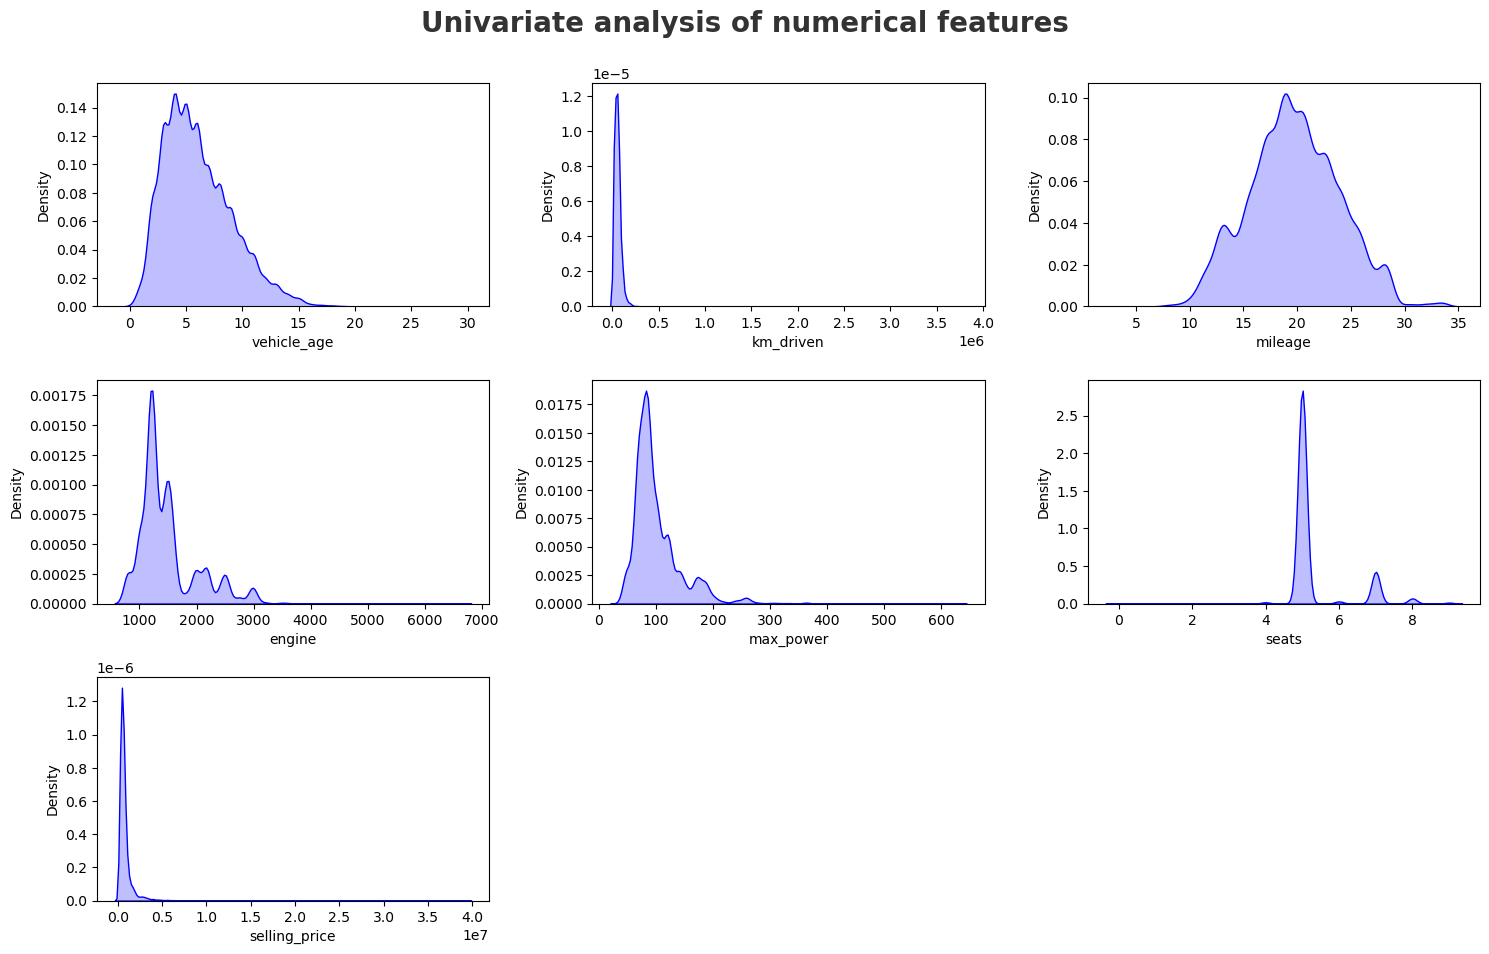

In [585]:
plt.figure(figsize = (15,15))
plt.suptitle("Univariate analysis of numerical features",fontsize=20, fontweight='bold',alpha = 0.8, y = 1)

for i in range(0,len(numerical_features)):
    plt.subplot(5,3,i+1)
    sns.kdeplot(x= df[numerical_features[i]],shade = True, color = 'b')
    plt.xlabel(numerical_features[i])
    plt.tight_layout()

plt.show()

### Observations

* km_driven, engine, max_power and selling_price are right skewed
* There are outliers present in km_driven, engine, max_power and selling_price

### Univariate analysis of categorical features

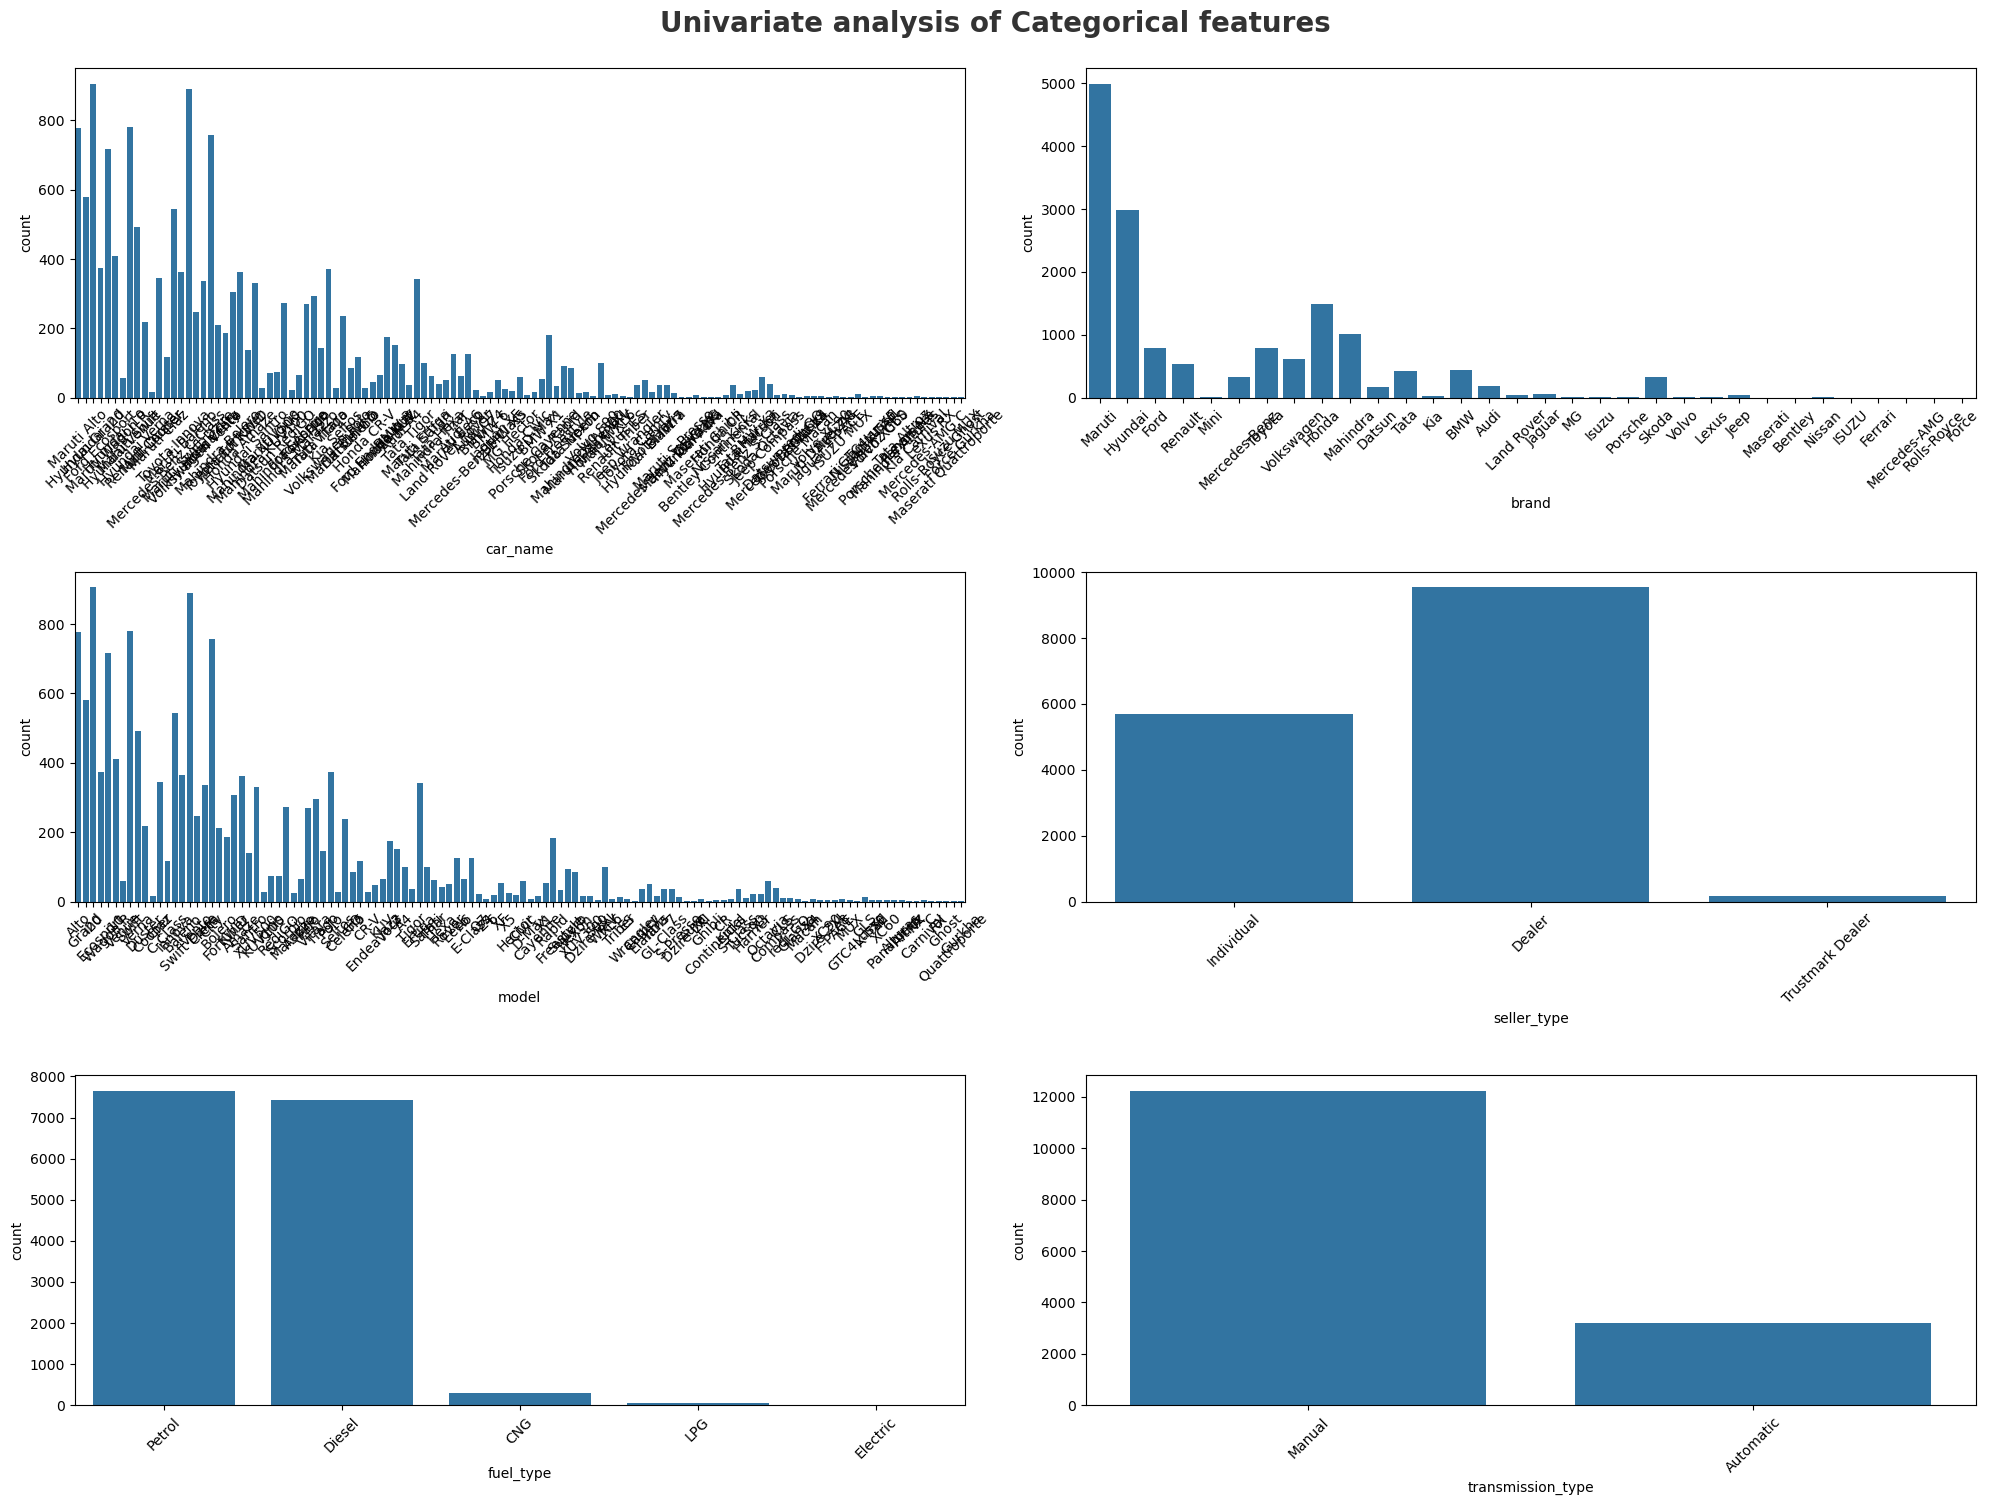

In [647]:
plt.figure(figsize = (20,15))
plt.suptitle('Univariate analysis of Categorical features',fontsize = 20, fontweight = 'bold', alpha = 0.8, y=1)
for i in range(0, len(categorical_features)):
    plt.subplot(3,2,i+1)
    sns.countplot(x = df[categorical_features[i]])
    plt.xlabel(categorical_features[i])
    plt.xticks(rotation = 45)
    plt.tight_layout()

plt.show()
    

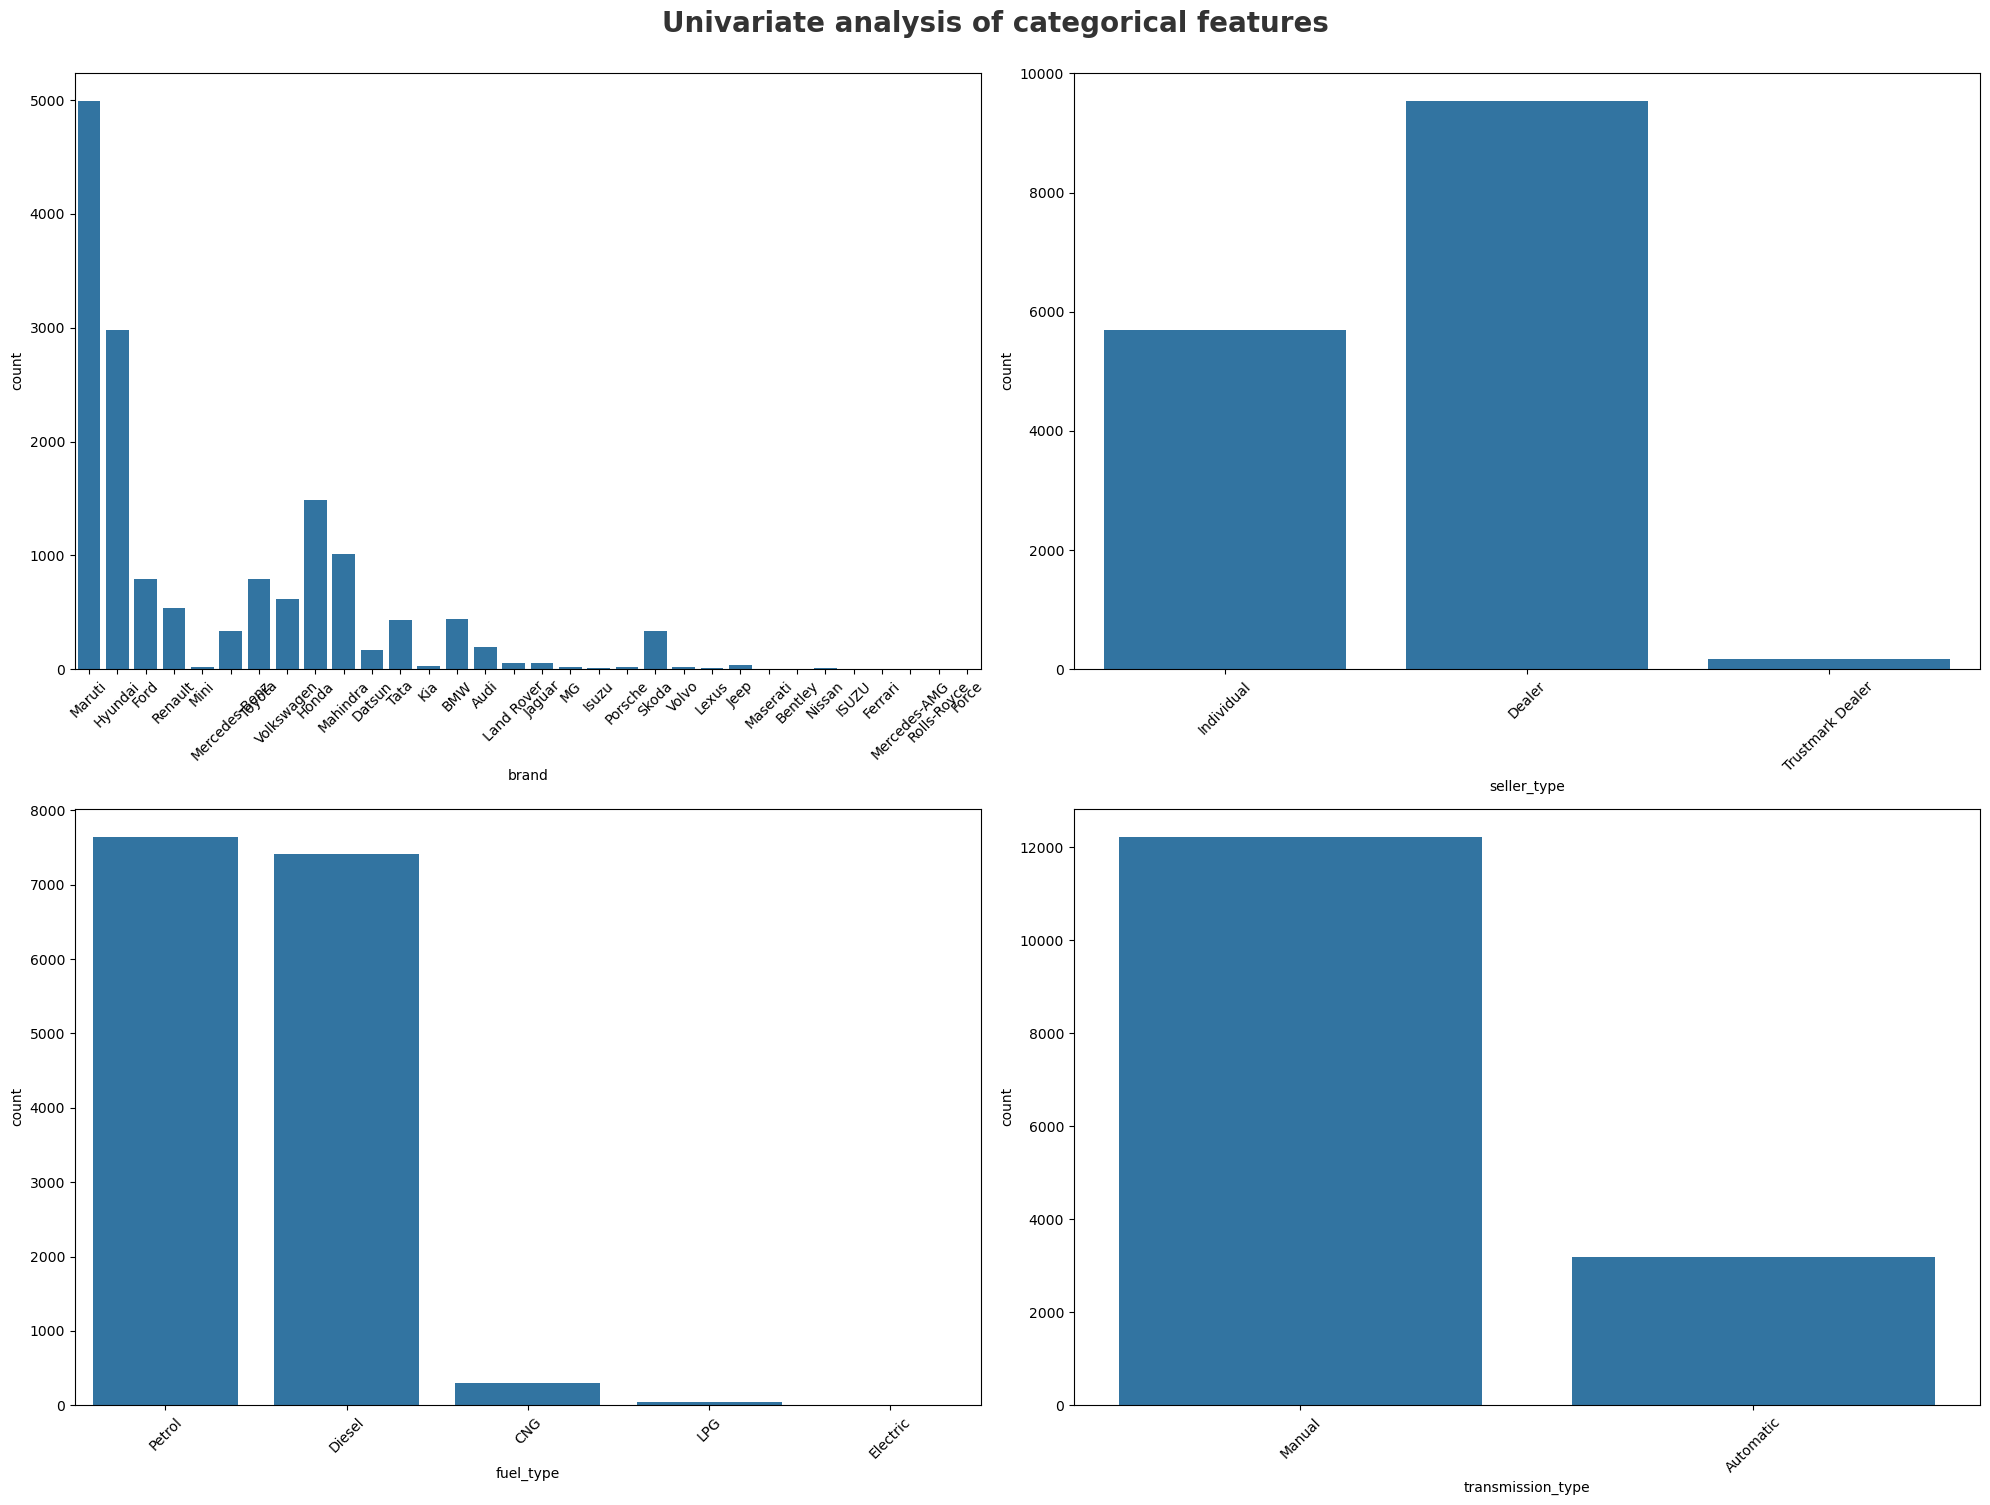

In [676]:
cat1 = ['brand', 'seller_type', 'fuel_type', 'transmission_type']
plt.figure(figsize = (20,15))
plt.suptitle('Univariate analysis of categorical features', fontsize = 20, fontweight = 'bold',alpha = 0.8, y=1.)
for i in range(0, len(cat1)):
    plt.subplot(2,2,i+1)
    sns.countplot(x = df[cat1[i]])
    plt.xlabel(cat1[i])
    plt.xticks(rotation = 45)
    plt.tight_layout()

plt.show()


## Multivariate analysis

* Multlivariate analysis refers to the analysis of more than one variable

### Check mutlicolinearity in numerical features

In [722]:
df[numerical_features].corr()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
vehicle_age,1.000000,0.333891,-0.257394,0.098965,0.005208,0.030791,-0.241851
km_driven,0.333891,1.000000,-0.105239,0.192885,0.044421,0.192830,-0.080030
mileage,-0.257394,-0.105239,1.000000,-0.632987,-0.533128,-0.440280,-0.305549
engine,0.098965,0.192885,-0.632987,1.000000,0.807368,0.551236,0.585844
max_power,0.005208,0.044421,-0.533128,0.807368,1.000000,0.172257,0.750236
seats,0.030791,0.192830,-0.440280,0.551236,0.172257,1.000000,0.115033
selling_price,-0.241851,-0.080030,-0.305549,0.585844,0.750236,0.115033,1.000000


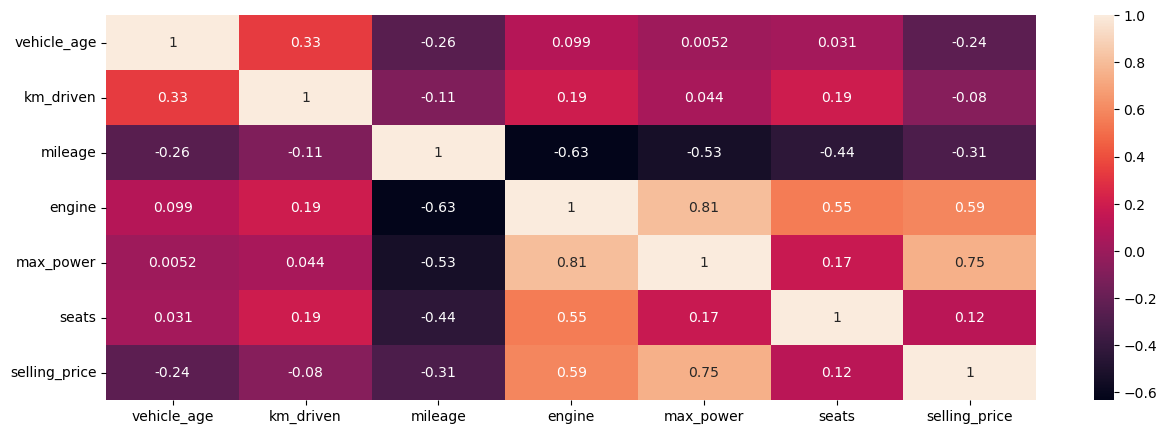

In [744]:
plt.figure(figsize = (15,5))
sns.heatmap(data = df[numerical_features].corr(),annot = True)
plt.show()

### Observations - 

* The selling price have a direct correlation with the max power generated by the car, higher the power implies higher price.
* The selling price has a negative impact on the kms driven by the car. Cars driven less are sold at a higher price.


In [811]:
df.columns

Index(['car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type',
       'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power',
       'seats', 'selling_price'],
      dtype='object')

In [818]:
continous_feature = [i for i in numerical_features if len(df[i].unique())>10]
continous_feature

['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'selling_price']

### Plotting data for continous_feature

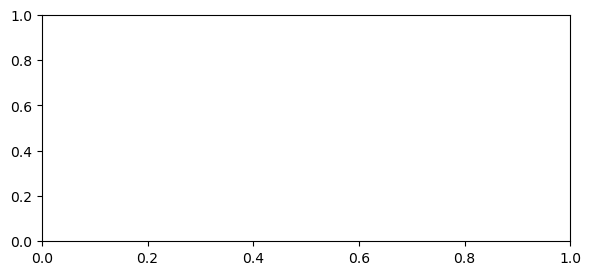

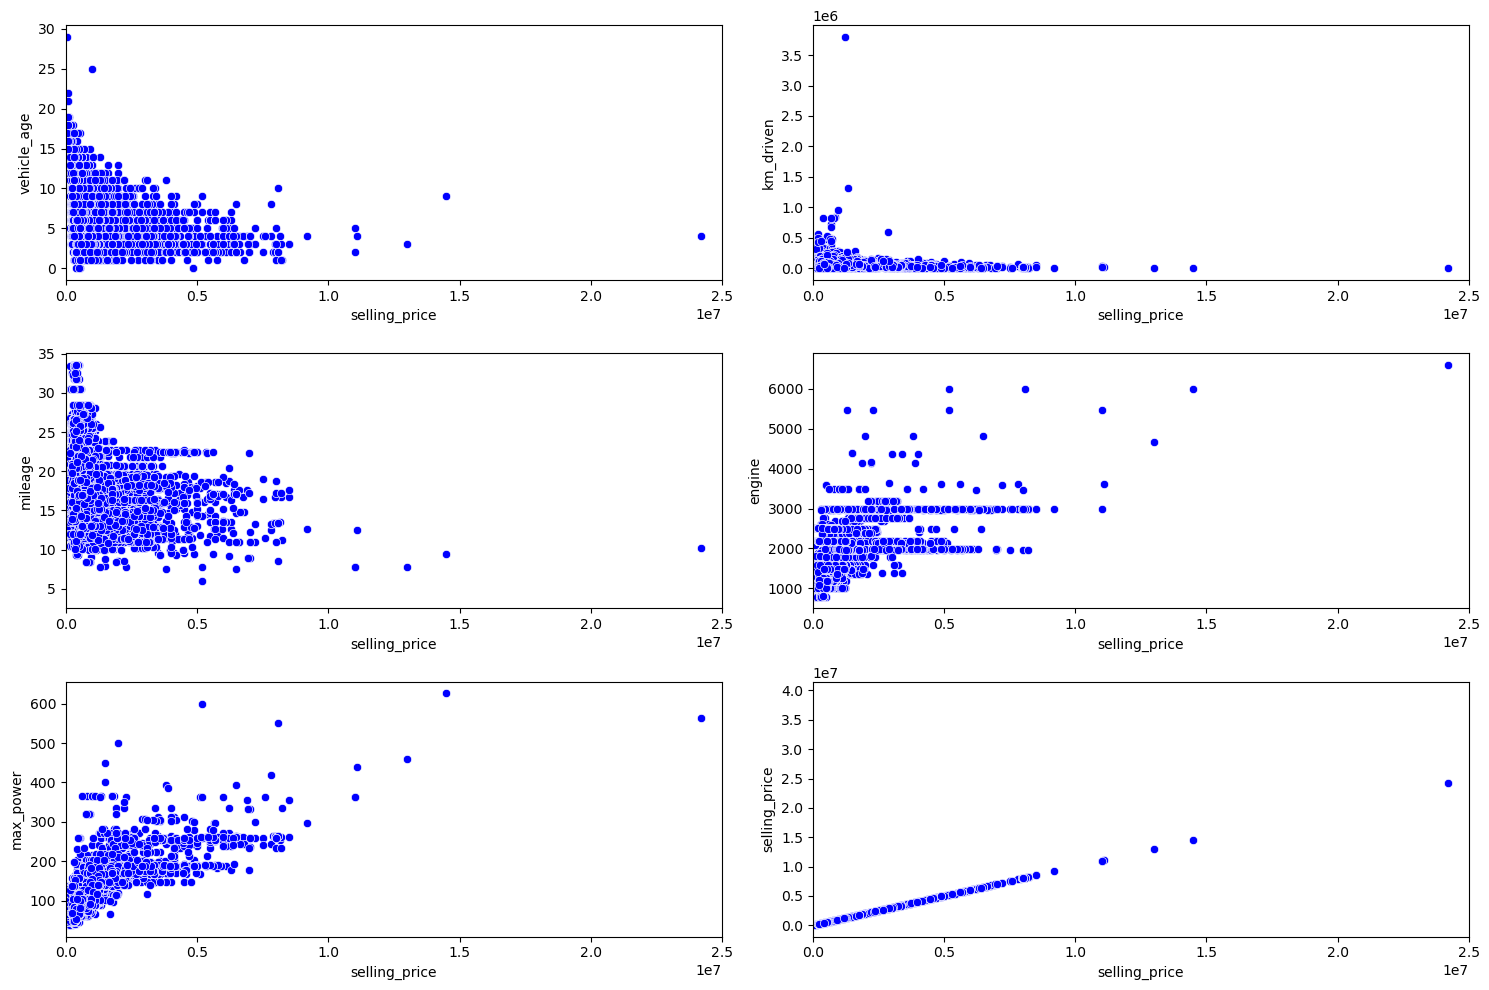

In [840]:
plt.figure(figsize = (15,10))
for i in range(0, len(continous_feature)):
    plt.subplot(3,2,i+1)
    sns.scatterplot(data = df,x = 'selling_price', y = continous_feature[i], color = 'b')
    plt.xlim(0,25000000)
    plt.tight_layout()

plt.show()

### Observations
1. The selling price is higher for those vehicles which have less age and are less driven
2. Maximum people are buying cars which give good avergage.


### Most selling car in Used car website

In [851]:
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [853]:
df['car_name'].value_counts()

car_name
Hyundai i20           906
Maruti Swift Dzire    890
Maruti Swift          781
Maruti Alto           778
Honda City            757
                     ... 
Mercedes-AMG C          1
Tata Altroz             1
Ferrari GTC4Lusso       1
Hyundai Aura            1
Force Gurkha            1
Name: count, Length: 121, dtype: int64

#### Observation - The most sold car is Hyundai i20 and among least are Hyundai Aura and Force Gurkha

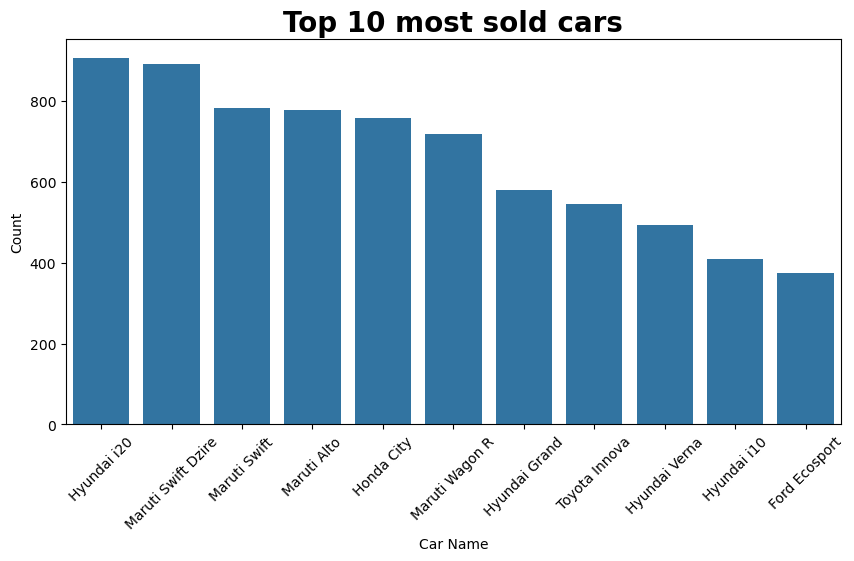

In [906]:
## Plotting graph for used car

plt.figure(figsize = (10,5))
sns.countplot(data = df, x = 'car_name', order= df['car_name'].value_counts().index)
plt.title("Top 10 most sold cars",fontsize = 20,weight = 'bold')
plt.xlabel('Car Name')
plt.ylabel('Count')
plt.xticks(rotation = 45)
plt.xlim(left= -0.5,right = 10.5)
plt.show()

In [908]:
## Checking mean price of Hyundai i20 

df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [934]:
m_price = df[df['car_name'] == 'Hyundai i20']['selling_price'].mean()
print('The mean price of Hyundai i20 is', m_price)

The mean price of Hyundai i20 is 543603.7527593819


### Most selling brand

In [946]:
df['brand'].value_counts()[0:10]

brand
Maruti        4992
Hyundai       2982
Honda         1485
Mahindra      1011
Toyota         793
Ford           790
Volkswagen     620
Renault        536
BMW            439
Tata           430
Name: count, dtype: int64

### Observation -
* The most sold brand is Maruti, followed by Hyundai

### Plotting graph of top 10 most sold brand

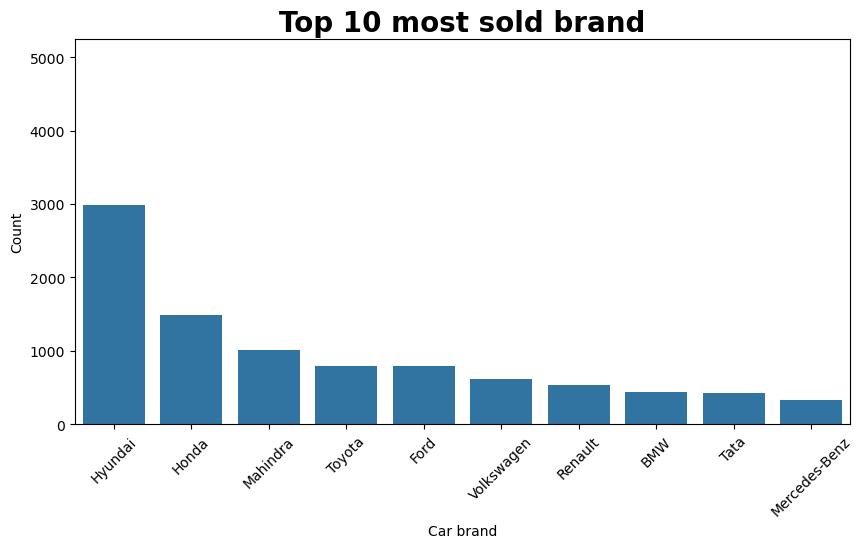

In [973]:
plt.figure(figsize = (10,5))
sns.countplot(data = df, x = 'brand',order = df['brand'].value_counts().index)
plt.title("Top 10 most sold brand",fontsize = 20, weight = 'bold')
plt.xlabel("Car brand")
plt.ylabel('Count')
plt.xticks(rotation = 45)
plt.xlim(left = 0.5, right = 10.5)
plt.show()

### Checking the mean price of Maruti brand which is sold most

In [1002]:
maruti = df[df['brand'] == 'Maruti']['selling_price'].mean()
print('The mean price of Maruti cars is', maruti)

The mean price of Maruti cars is 487089.3179086539


### Finding the costliest brand and costliest car

In [1026]:
df['selling_price'].max()

39500000

In [1028]:
df[df['selling_price'] == 39500000]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
4845,Ferrari GTC4Lusso,Ferrari,GTC4Lusso,2,3800,Dealer,Petrol,Automatic,4.0,3855,601.0,4,39500000


* The costliest brand is Ferrari and it's car Ferrari GTC4Lusso is price at 39500000, which id hightest

In [1055]:
# Other way

brand = df.groupby('brand').selling_price.max()
brand_df = brand.to_frame().sort_values(by = 'selling_price',ascending = False)[0:10]
brand_df

,selling_price
brand,
Ferrari,39500000
Rolls-Royce,24200000
Bentley,14500000
Mercedes-Benz,13000000
Porsche,11100000
Land Rover,9200000
BMW,8500000
Volvo,8195000
Lexus,8000000


In [1109]:
brand.sor

brand
Audi              6800000
BMW               8500000
Bentley          14500000
Datsun             650000
Ferrari          39500000
Force              700000
Ford              3200000
Honda             3200000
Hyundai           2600000
ISUZU             1900000
Isuzu             2300000
Jaguar            6300000
Jeep              5600000
Kia               3525000
Land Rover        9200000
Lexus             8000000
MG                2075000
Mahindra          2950000
Maruti            1225000
Maserati          6200000
Mercedes-AMG      5100000
Mercedes-Benz    13000000
Mini              3875000
Nissan            1450000
Porsche          11100000
Renault           1155000
Rolls-Royce      24200000
Skoda             3550000
Tata              1750000
Toyota            3650000
Volkswagen        1250000
Volvo             8195000
Name: selling_price, dtype: int64

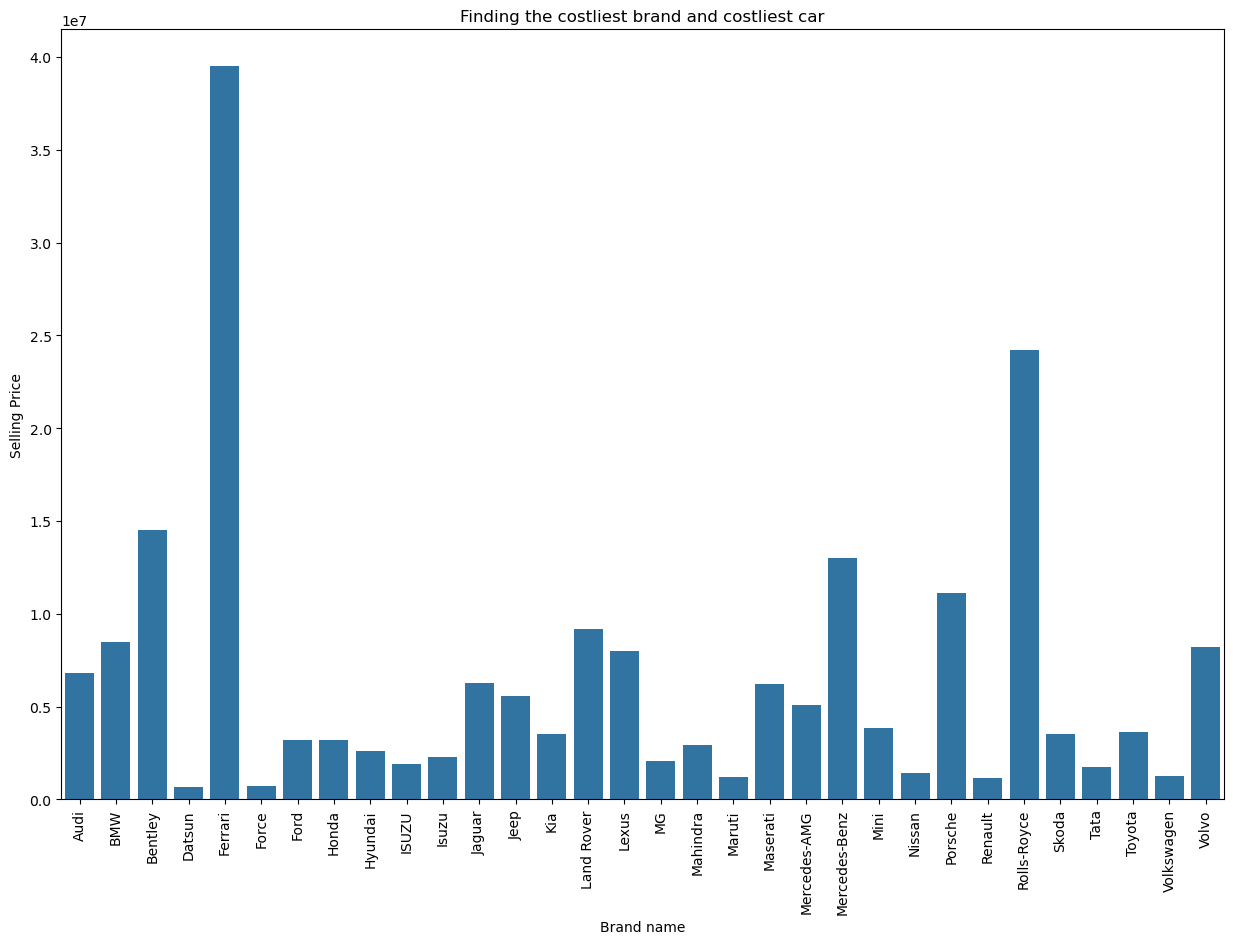

In [1164]:
# Plotting graph for above result

#plt.subplots(figsize = (15,7))
plt.figure(figsize = (15,10))
plt.title("Finding the costliest brand and costliest car")
sns.barplot(x = brand.index, y= brand.values)
plt.xlabel("Brand name")
plt.ylabel("Selling Price")
plt.xticks(rotation = 90)
plt.show()

In [ ]:
# Same result can be seen that Ferrari has the highest car price

### Most mileage brand and car name

In [1116]:
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [1124]:
df['mileage'].max()

33.54

In [1128]:
df[df['mileage'] == df['mileage'].max()]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
224,Maruti Wagon R,Maruti,Wagon R,3,52000,Dealer,CNG,Manual,33.54,998,67.04,5,435000
239,Maruti Wagon R,Maruti,Wagon R,8,64000,Dealer,CNG,Manual,33.54,998,67.04,5,270000
1606,Maruti Wagon R,Maruti,Wagon R,4,32013,Trustmark Dealer,CNG,Manual,33.54,998,67.04,5,380000
2023,Maruti Wagon R,Maruti,Wagon R,6,55000,Dealer,CNG,Manual,33.54,998,67.04,5,335000
2903,Maruti Wagon R,Maruti,Wagon R,9,62000,Dealer,CNG,Manual,33.54,998,67.04,5,340000
2948,Maruti Wagon R,Maruti,Wagon R,7,135975,Dealer,CNG,Manual,33.54,998,67.04,5,295000
3019,Maruti Wagon R,Maruti,Wagon R,8,63000,Dealer,CNG,Manual,33.54,998,67.04,5,351000
3500,Maruti Wagon R,Maruti,Wagon R,8,55853,Dealer,CNG,Manual,33.54,998,67.04,5,349000
3716,Maruti Wagon R,Maruti,Wagon R,3,32000,Dealer,CNG,Manual,33.54,998,67.04,5,485000
4270,Maruti Wagon R,Maruti,Wagon R,5,64224,Dealer,CNG,Manual,33.54,998,67.04,5,375000


#### Observation - 
* We can see that Maruti Wagon R car has the most mileage and it is of Maruti brand

In [1168]:
# Other way to find above result

m_brand = df[['car_name','mileage']]
#m_brand.sort_values(by = 'mileage', ascending = False)[0:10]
m_brand_sort = m_brand.groupby(by = 'car_name')['mileage'].mean().sort_values(ascending = False)[0:10]
m_brand_sort

car_name
Tata Tiago          24.625103
Maruti Ciaz         24.289046
Maruti Vitara       24.231932
Renault KWID        24.037810
Maruti Celerio      23.703502
Maruti Dzire VXI    23.512941
Maruti Dzire LXI    23.260000
Maruti Dzire ZXI    23.260000
Ford Aspire         22.993846
Maruti Swift        22.719910
Name: mileage, dtype: float64

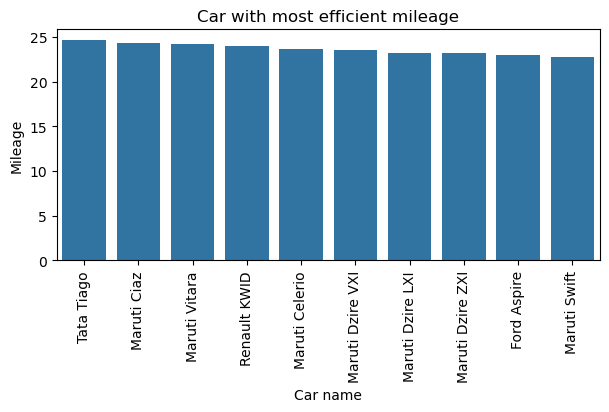

In [1174]:
plt.figure(figsize = (7,3))
plt.title("Car with most efficient mileage")
sns.barplot(x = m_brand_sort.index, y = m_brand_sort.values)
plt.xlabel("Car name")
plt.ylabel("Mileage")
plt.xticks(rotation = 90)
plt.show()

In [ ]:
# Observation - We changed our approach a little bit in above result of plotting bar plot. Instead of taking the max values for mileage for each car
            #   we took the mean of all the car name present in group by format, so the result is different

### Km driven vs selling price

In [1177]:
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

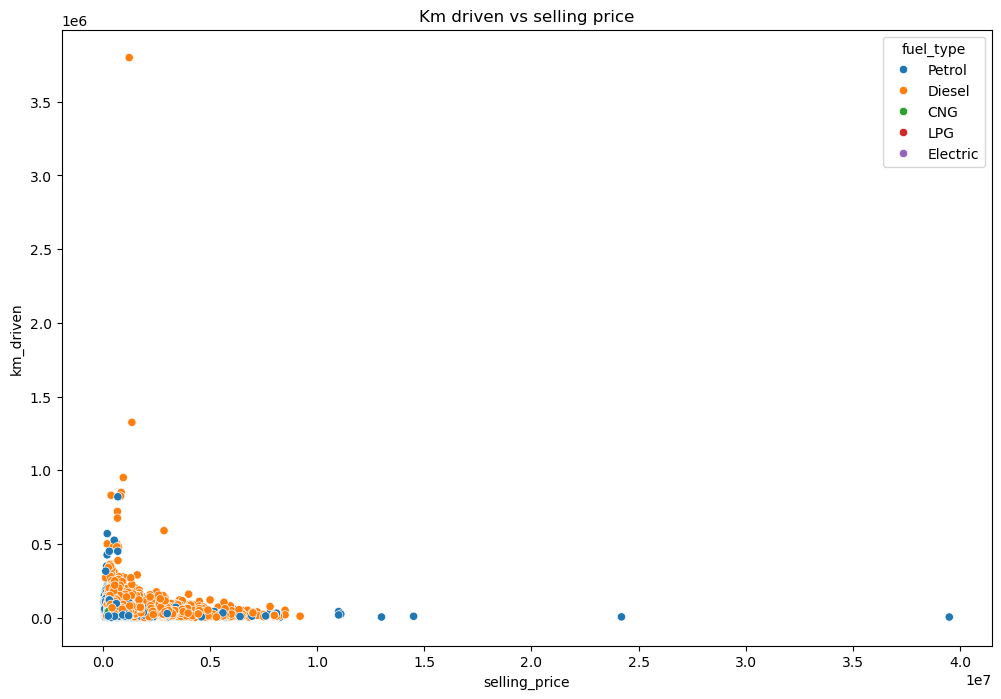

In [1214]:
plt.figure(figsize = (12,8))
sns.scatterplot(x = df['selling_price'],y = df['km_driven'],hue = df['fuel_type'])
plt.title("Km driven vs selling price")
plt.xlabel("selling_price")
plt.ylabel("km_driven")
plt.show()

#### Observation - 
* Low kms driven cars had higher selling price as compared to higher km driven

### Fuel type selling price

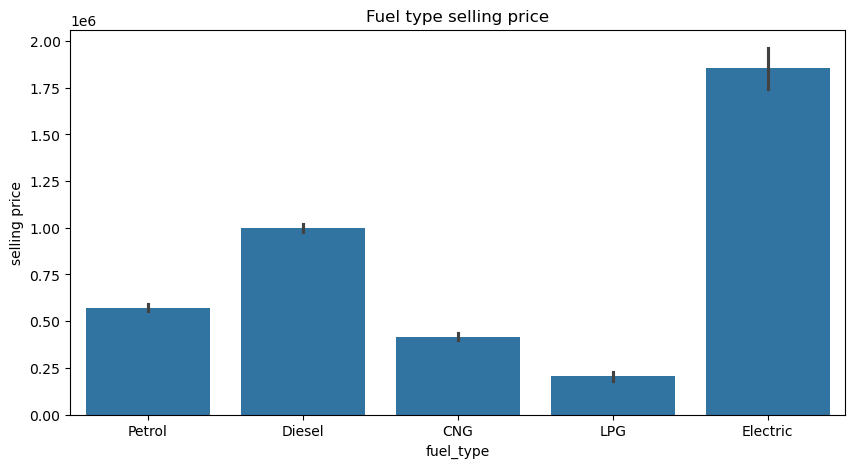

In [1270]:
plt.figure(figsize = (10,5))
plt.title("Fuel type selling price")
plt.xlabel("fuel_type")
plt.ylabel("selling price")
sns.barplot(x = df['fuel_type'],y = df['selling_price'])
plt.show()

#### Observation

* Electric cars have selling price as compared to other type of cars
* LPG cars is having lowest price

### Fuel type count

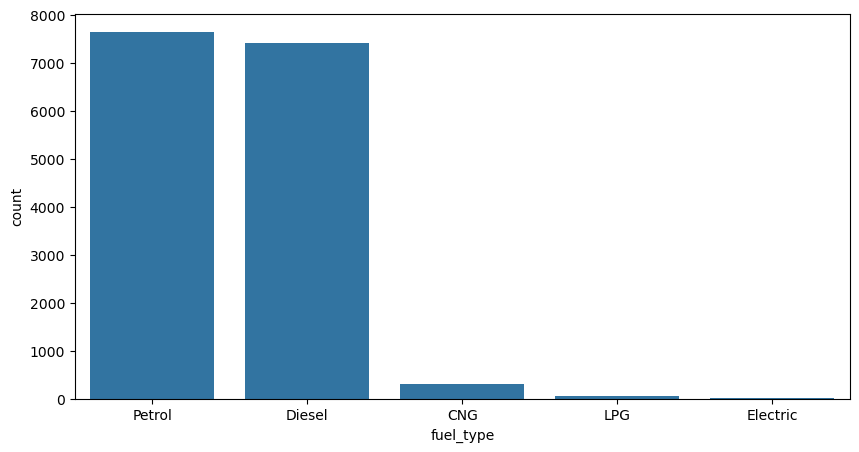

In [1275]:
plt.figure(figsize = (10,5))
sns.countplot(x = df['fuel_type'])
plt.show()

#### Observation - 
* Pertol cars is highest sold, followed by Diesel
* Electric cars is least sold

### Mileags vs selling price

In [1281]:
df.head(1)

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.7,796,46.3,5,120000


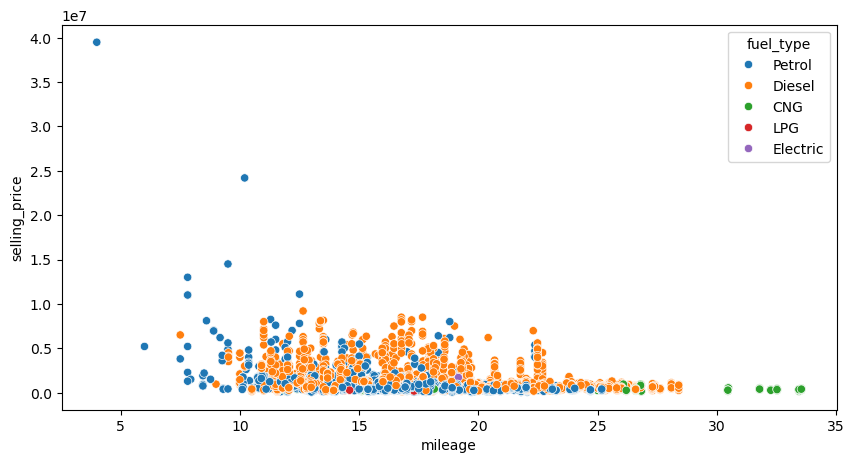

In [1285]:
plt.figure(figsize = (10,5))
sns.scatterplot(x = df['mileage'],y = df['selling_price'],hue = df['fuel_type'])
plt.show()

### Observation

* Maximum cars are sold with mileage range as 10-20 km/litre
* CNG cars give the highest mileage but their selling price is not high
